
<div dir=ltr align=center>

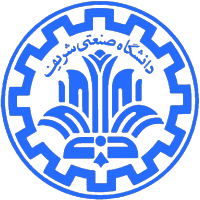

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Dimensionality Reduction: Principal Component Analysis<br>
<font color=696880 size=4>
    Prepared by Fatemeh Khojasteh <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [99]:
student_number = '403206962'
full_name = 'Mobina Poulaei'

# Image Compression with PCA (From Scratch)

## Objective
 The goal of this assignment is to gain a deep understanding of **Principal Component Analysis (PCA)** by implementing it from scratch and applying it to image compression.

## Problem Statement
 Consider a grayscale image. We want to reduce its dimensionality by dividing the image into small "patches" and treating each patch as a data vector.

**Workflow:**
 1.  **Image Preparation:** Load the local image and convert it to grayscale.
 2.  **Patch Extraction:** Divide the image into small squares (e.g., $12 \times 12$). Each patch, when flattened, becomes a vector of dimension $144$.
 3.  **PCA Implementation:** Complete the `PCAFromScratch` class. You must calculate the covariance matrix, find eigenvalues/eigenvectors, and project data into a lower-dimensional space.
 4.  **Compression & Reconstruction:** Project the patches into a lower-dimensional space (e.g., 16 dimensions) and then reconstruct them back to 144 dimensions.
 5.  **Stitching:** Reassemble the reconstructed patches to form the final image.
 6.  **Visualization:** Visualize the top 16 Principal Components (Eigenfaces/Eigenpatches).


## Rules & Constraints
 1.  **No `sklearn`:** You are **NOT** allowed to use `sklearn.decomposition.PCA`. You must implement the logic using `numpy` (functions like `np.cov`, `np.linalg.eig`, `np.linalg.svd` are allowed).
 2.  **Allowed Libraries:** `numpy`, `matplotlib`, `cv2` (or `PIL`).
 3.  **Flexibility:** Your code should handle images that may not be perfectly divisible by the patch size (you should implement cropping logic).


In [100]:
# Import needed libraries

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

## Part 1: PCA Class Implementation

 In this section, you must implement the PCA algorithm from scratch.

 **Implementation Steps for `fit`:**
 1. Calculate the mean of the columns.
 2. Center the data ($X - \text{mean}$).
 3. Compute the Covariance Matrix.
 4. Compute Eigenvalues and Eigenvectors.
 5. Sort Eigenvectors by Eigenvalues in descending order.
 6. Store the top `n_components` eigenvectors.

In [101]:
class PCAFromScratch:
    def __init__(self, n_components):
        """
        n_components: The number of dimensions to keep (k).
        """
        self.n_components = n_components
        self.components = None      # Store the selected eigenvectors (W) here
        self.mean = None            # Store the mean of the training data here

    def fit(self, X):
        """
        X: Input data matrix of shape (n_samples, n_features)
        This method should learn the parameters (mean and eigenvectors).
        """
        self.mean = np.mean(X, axis=0)
        self.X_centered = X - self.mean
        cov_matrix = np.cov(self.X_centered, rowvar=False) # (n_features, n_features)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]
        self.eigenvectors = eigenvectors[:, sorted_indices] # (n_features, n_features)
        self.components = self.eigenvectors[:, :self.n_components] # (n_features, n_components)

    def transform(self, X):
        """
        Projects X into the lower-dimensional space.
        X: (n_samples, n_features)
        Returns: (n_samples, n_components)
        """
        return np.dot(self.X_centered, self.components)

    def inverse_transform(self, X_transformed):
        """
        Reconstructs X from the lower-dimensional space.
        X_transformed: (n_samples, n_components)
        Returns: (n_samples, n_features)
        """
        return np.dot(X_transformed, self.components.T) + self.mean

## Part 2: Patch Extraction Logic

 Implement functions to convert an image into a matrix of patches and vice versa.

 *Hint: It is easier to crop the image first so that its dimensions are divisible by the patch size.*


In [102]:
def get_valid_image_dims(image, patch_size):
    """It crops the image in a way that its dimensions are divisible by the patch size."""
    h, w = image.shape
    ph, pw = patch_size
    new_h = (h // ph) * ph
    new_w = (w // pw) * pw
    return image[:new_h, :new_w]  # Return the cropped image

def image_to_patches(image, patch_size=(12, 12)):
    """
    Input: Image (H, W)
    Output: Tuple of (patches_matrix, valid_image_shape)
            - patches_matrix shape: (N_patches, flattened_patch_size)
            - valid_image_shape: (H_cropped, W_cropped)
    """
    image = get_valid_image_dims(image, patch_size)
    h, w = image.shape
    ph, pw = patch_size

    n_h = h // ph
    n_w = w // pw

    patches = image.reshape(n_h, ph, n_w, pw)
    patches = patches.transpose(0, 2, 1, 3)
    patches_matrix = patches.reshape(-1, ph * pw)
    return patches_matrix, (h, w)

def patches_to_image(patches, original_shape, patch_size=(12, 12)):
    """
    Input:
        - patches: (N, 144) matrix
        - original_shape: (H, W) of the cropped image
    Output: Reconstructed Image (H, W)
    """
    ph, pw = patch_size
    h, w = original_shape

    n_h = h // ph
    n_w = w // pw

    patches = patches.reshape(n_h, n_w, ph, pw)
    patches = patches.transpose(0, 2, 1, 3)
    image = patches.reshape(h, w)

    return image

## Part 3: Execution Pipeline

 Write the code to execute the PCA pipeline.

 1. Load the image.
 2. Convert image to patches.
 3. Run PCA.
 4. Reconstruct image.
 5. Calculate error.

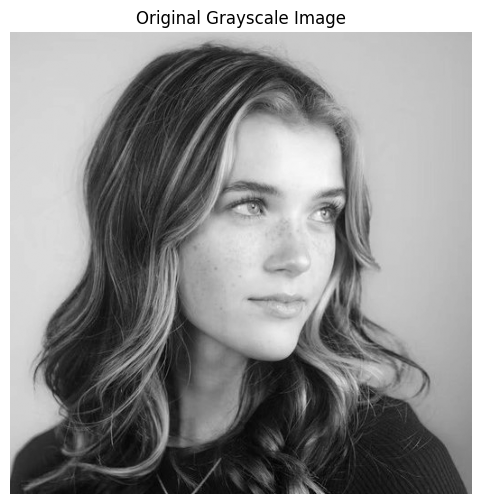

In [103]:
# --- 1. Load Image ---
# Ensure 'image.jpg' is in the same directory
IMAGE_PATH = '/content/image.jpg'
img = Image.open(IMAGE_PATH).convert('L') # Convert to Grayscale
original_image = np.array(img)

plt.figure(figsize=(6, 6))
plt.title("Original Grayscale Image")
plt.imshow(original_image, cmap='gray')
plt.axis('off')
plt.show()

In [104]:
# --- 2. Prepare Data ---
PATCH_SIZE = (12, 12)
patches, valid_shape = image_to_patches(original_image, patch_size=PATCH_SIZE)
print(f"Original Image Shape: {original_image.shape}")
print(f"Valid Image Shape (Cropped): {valid_shape}")
print(f"Patches Matrix Shape: {patches.shape}")

Original Image Shape: (512, 512)
Valid Image Shape (Cropped): (504, 504)
Patches Matrix Shape: (1764, 144)


In [105]:
# --- 3. Train PCA ---
N_COMPONENTS = 16
pca = PCAFromScratch(n_components=N_COMPONENTS)
pca.fit(patches)

total_variance = np.sum(pca.eigenvalues)
explained_variance = np.sum(pca.eigenvalues[:N_COMPONENTS])

evr = explained_variance / total_variance
print(f"Explained Variance Ratio (Top {N_COMPONENTS}): {evr * 100:.2f}%")

Explained Variance Ratio (Top 16): 99.09%


In [106]:
# --- 4. Compress & Reconstruct ---
# TODO: Transform the patches to the lower-dimensional space (Compression)
compressed_patches = pca.transform(patches)
# TODO: Inverse transform the compressed data back to the original space (Reconstruction)
reconstructed_patches = pca.inverse_transform(compressed_patches)
# TODO: Print the shapes of the compressed and reconstructed data
print("Compressed Shape:", compressed_patches.shape)
print("Reconstructed patches Shape:", reconstructed_patches.shape)

Compressed Shape: (1764, 16)
Reconstructed patches Shape: (1764, 144)


In [107]:
# --- 5. Reassemble Image ---
# TODO: Use patches_to_image to reconstruct the full image from the patches
reconstructed_image = patches_to_image(reconstructed_patches,valid_shape,patch_size=PATCH_SIZE)
# TODO: Calculate Mean Squared Error (MSE) between the original (cropped) image and the reconstruction
original_cropped = original_image[:valid_shape[0], :valid_shape[1]]
mse = np.mean((original_cropped - reconstructed_image) ** 2)
print(f"Reconstruction MSE: {mse}")

Reconstruction MSE: 25.356196252234476


## Part 4: Visualization

 Visualize the results and the learned features.


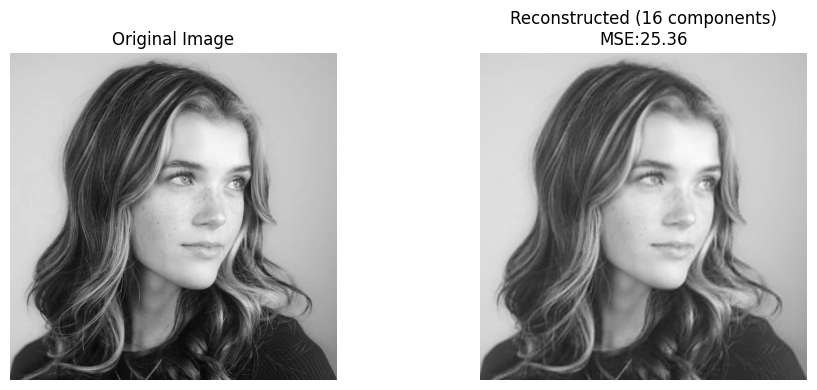

In [108]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_cropped, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Reconstructed (16 components)\nMSE:{round(mse, 2)}")
plt.imshow(reconstructed_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## 1. Quality Comparison (Reconstruction Quality)

In the image above, you can see the original image next to the reconstructed one.

* **Interpretation:** The image on the right has been reconstructed using only **16 components**. Even though the data dimensions have been reduced by 9 times (from 144 features per patch to 16 features), the image is still easily recognizable.
* **Quality Loss:** If you look closely, the reconstructed image appears slightly "blurry," and high-frequency details (such as very fine textures on the hat or hair) have been removed. This is the price we pay for compression.
* **MSE:** The MSE (Mean Squared Error) value indicates the average squared error between the original and reconstructed pixels.


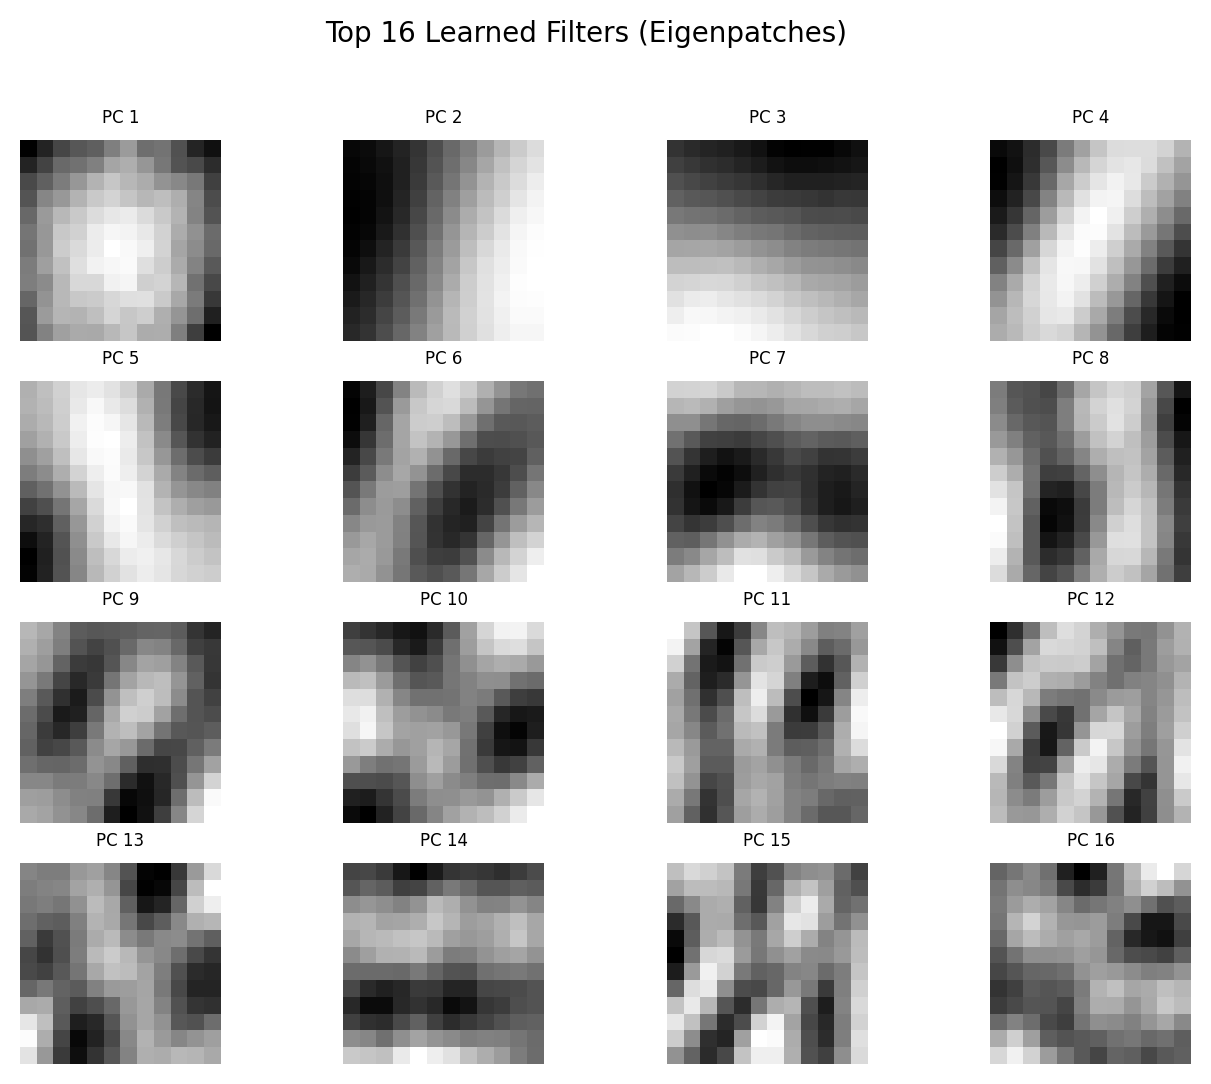

In [109]:
# TODO: Visualize the top 16 Eigenvectors (The "Eigenpatches")
# Hint: You need to reshape pca.components from (144, 16) back to (12, 12) grid images.
# Display them in a 4x4 grid.

plt.figure(figsize=(8, 6), dpi=200)
for i in range(16):
    eigenpatch = pca.components[:, i].reshape(12, 12)
    plt.subplot(4, 4, i + 1)
    plt.imshow(eigenpatch, cmap='gray')
    plt.title(f"PC {i + 1}", fontsize=6)
    plt.axis('off')

plt.suptitle("Top 16 Learned Filters (Eigenpatches)", fontsize=10)
plt.show()

In the image above, you can see the top 16 eigenvectors, which have been reshaped to dimensions of $12 \times 12$.

* **What are these?** These small squares are actually the "building blocks" of the image. The PCA algorithm has extracted these patterns from the Lenna image. Each patch in the final image is a linear combination of these 16 shapes.
* **Pattern Analysis:**
    * **Initial components (like PC1 and PC2):** Typically represent overall lighting changes and simple gradients (low frequency).
    * **Middle components:** Start to display directions (horizontal, vertical, or diagonal edges).
    * **Final components:** Model more complex details and fine textures (high frequency).
* **Why are they checkerboard-like?** These patterns are orthogonal and aim to cover the maximum variance present in the data.
